## MedBuddy.ML - Heart Disease Risk Prediction
#### Dataset: heart.csv
1.setup

In [1]:
# install required libraries - can also executed in the terminal in .venv
# %pip install -r requirements.txt

In [2]:
pip install -r C:\Users\SHREY\Desktop\ml-med-Buddy-ml\requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# importing required Libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint,uniform

from sklearn.model_selection import GroupShuffleSplit,StratifiedGroupKFold,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score,
)

In [4]:
# Configuration
pd.set_option('display.max_columns',None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")
sns.set_theme(style = "darkgrid")

RANDOM_STATE = 42
CSV_PATH =r"C:\Users\SHREY\Desktop\ml-med-Buddy-ml\dataset\heart.csv"
TARGET_COL = "target"

2.Load Data

In [5]:
df = pd.read_csv(CSV_PATH)
print("Dataset shape:",df.shape)
display(df.head())

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


3.EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features = [
  "sex",
   "cp",
   "fbs",
   "restecg",
   "exang",
   "slope",
   "thal",
   "target"
]

print("Numerical features:",numerical_features)
print("Categorical features:",categorical_features)

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [8]:
# Missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
#quick check for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
Name: count, dtype: int64
sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
Name: count, dtype: int64
chol
204    21
234    21
197    19
212    18
254    17
269    16
177    14
282    14
240    14
211    13
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
thalach
162    35
160    31
163    29
173    28
152    28
144    26
132    26
125    25
150    25
143    23
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
oldpeak
0.000    329
1.200     58
1.000     51
0.600     47
0.800     44
1.400     44
1.600     37
0.200     37
1.800     36
2.000     32
Name: count, dtype: int64
slope
1    482
2    469
0     74
N

In [10]:
#duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print(f"Number of duplicate rows: {num_duplicates}")

# (optional) drop duplicates 
#df = df.drop_duplicates()
#print("Dataset shape after dropping duplicates:",df.shape)

Number of duplicate rows: 723


Although the dataset contains a large number of duplicate rows , these likely represent multiple real-world patients with identical clinical measurements .Dropping these rows would drastically reduce the datasize and distort the natural frequency of observation in the data

We therefore retain duplicate rows,but take special care during validation .To ensure fair evaluation, we use group-based splitting (Group -K FOLD) so that identical data points are never shared between training and validatiop folds.

While tree-based models are robust to duplicate observation during training ,preventing duplicate leakage across folds is essential and unbiased performance estimates.

In [11]:
# target distribution
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True)*100)

target
1    526
0    499
Name: count, dtype: int64
--------------------------------------------------
target
1   51.317
0   48.683
Name: proportion, dtype: float64


In [12]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200
ca,1025.000,0.754,1.031,0.000,0.000,0.000,1.000,4.000


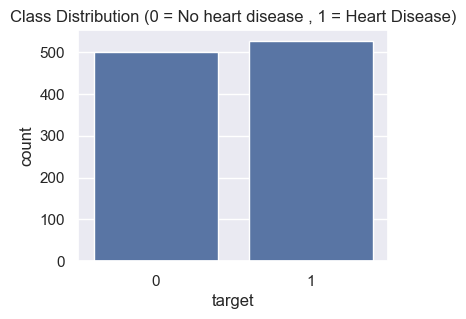

In [13]:
# Visualize target distribution
plt.figure(figsize=(4,3))
sns.countplot(x=TARGET_COL,data = df)
plt.title("Class Distribution (0 = No heart disease , 1 = Heart Disease)")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_Layout'

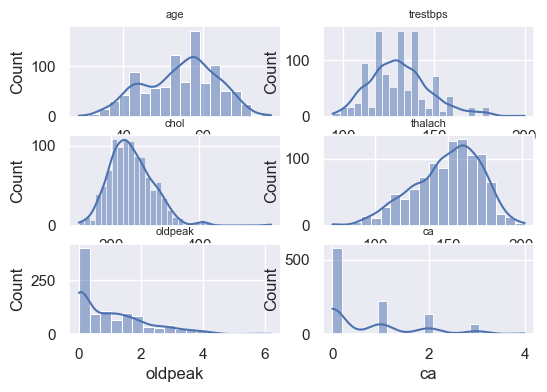

In [14]:
fig,axes = plt.subplots(3,2,figsize=(6,4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde = True, ax = axes[i])
    axes[i].set_title(col,fontsize = 8)

plt.tight_Layout()
plt.show()

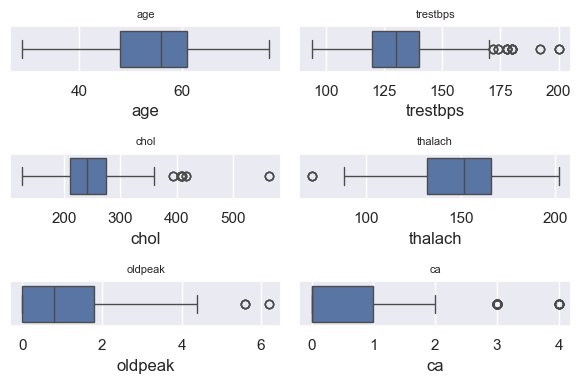

In [15]:
#outliers analyst - boxplot
fig,axes = plt.subplots(3,2,figsize=(6,4))
axes = axes.flatten()

for i,col in enumerate(numerical_features):
    sns.boxplot(x=df[col],ax = axes[i])
    axes[i].set_title(col,fontsize = 8)

plt.tight_layout()
plt.show()

Not much outliers .We can leave it

Text(0.5, 1.0, 'Correlation Heatmap')

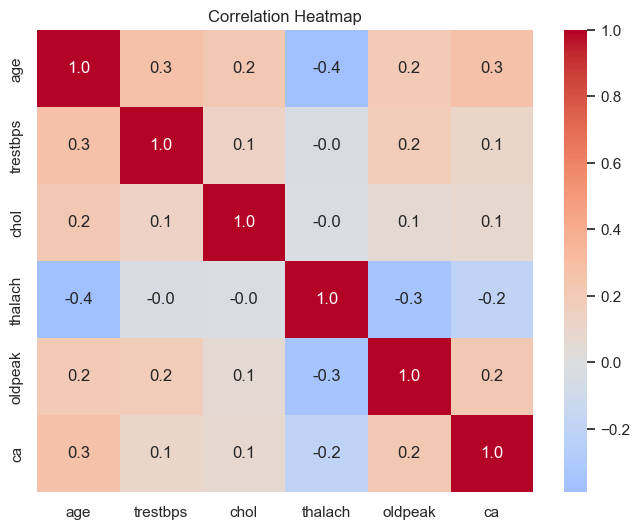

In [16]:
# Identify presence of highly correlated & feature re;atiopnships
plt.figure(figsize=(8,6))
sns.heatmap(
    df[numerical_features].corr(),
    cmap = "coolwarm",
    annot = True,
    fmt = ".1f",
    center = 0
)
plt.title("Correlation Heatmap")

No Highly correlated columns

4.Data Preprocessing

In [17]:
# Seperate X and y
X = df.drop(columns = [TARGET_COL])
y = df[TARGET_COL]

# Create a signature for each feature row - to prevent duplicate flow to test set
row_signatures = pd.util.hash_pandas_object(X,index = False)

In [18]:
print("Unique row signatures:",row_signatures.nunique())

Unique row signatures: 302


In [19]:
# Split data into train and test set using GroupShuffleSplit
gss = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.2,
    random_state = RANDOM_STATE
)

train_idx, test_idx = next(gss.split(X,y,groups = row_signatures))

X_train, X_test = X.iloc[train_idx],X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx],y.iloc[test_idx]

print("Train set shape:",X_train.shape)
print("Test set shape:",X_test.shape)

Train set shape: (817, 13)
Test set shape: (208, 13)


In [20]:
print("Dataset Size:",X.shape)
print("Train Dataset Size:",X_train.shape)
print("Test Dataset Size:",X_test.shape)

Dataset Size: (1025, 13)
Train Dataset Size: (817, 13)
Test Dataset Size: (208, 13)


5.Baseline Model - Logistic Regression

In [21]:
base_pipe = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("model",LogisticRegression())
    ]
)

In [22]:
# Training the base piepline
base_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [23]:
# resuable evaluation function
def evaluate_classifier(model,X_train,y_train,X_test,y_test,model_name):
    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train,y_train_pred)*100
    test_acc = accuracy_score(y_test,y_test_pred)*100   

    # Result
    print(f"{model_name}- Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name}- Test Accuracy: {test_acc:.2f}%")
    print("-"*50)

    print("Train Classification Report:")
    print(classification_report(y_train,y_train_pred))

    print("-"*40)

    print("Test Classification Report:")
    print(classification_report(y_test,y_test_pred))

In [24]:
evaluate_classifier(
    base_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name = "Logistic Regression"
)

Logistic Regression- Train Accuracy: 87.15%
Logistic Regression- Test Accuracy: 82.69%
--------------------------------------------------
Train Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       401
           1       0.85      0.90      0.88       416

    accuracy                           0.87       817
   macro avg       0.87      0.87      0.87       817
weighted avg       0.87      0.87      0.87       817

----------------------------------------
Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80        98
           1       0.79      0.92      0.85       110

    accuracy                           0.83       208
   macro avg       0.84      0.82      0.82       208
weighted avg       0.84      0.83      0.82       208



6.Model Selection

In [25]:
models = {
    "Logistic Regression": LogisticRegression(random_state = RANDOM_STATE),
    "Support Vector Machine":SVC(random_state = RANDOM_STATE),
    "Random Forest":RandomForestClassifier(random_state = RANDOM_STATE),
    "XGBoost":XGBClassifier(random_state = RANDOM_STATE)
}

In [26]:
groups = pd.util.hash_pandas_object(X_train,index = False)

k = 5
cv = StratifiedGroupKFold(n_splits = k, shuffle = True, random_state = RANDOM_STATE)

In [27]:
for name, model in models.items():
    recall_scores = []
    f1_scores = []

    for tr_idx,te_idx in cv.split(X_train,y_train,groups = groups):
        X_tr, X_te = X_train.iloc[tr_idx],X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx],y_train.iloc[te_idx]

        pipeline = Pipeline(
            steps = [
                ("scaler",StandardScaler()),
                ("model",model)
            ]
        )
        pipeline.fit(X_tr,y_tr)
        pred = pipeline.predict(X_te)

        recall_scores.append(round(recall_score(y_te,pred),2))
        f1_scores.append(round(f1_score(y_te,pred),2))

    print("Model Name:",name)
    print("Recall Scores:",recall_scores)
    print("F1 Scores:",f1_scores)
    print("\nCV Recall mean:",round(float(np.mean(recall_scores)),2))
    print("CV F1 Score mean:",round(float()))
          

Model Name: Logistic Regression
Recall Scores: [0.83, 0.86, 0.77, 0.84, 0.96]
F1 Scores: [0.85, 0.85, 0.78, 0.81, 0.84]

CV Recall mean: 0.85
CV F1 Score mean: 0
Model Name: Support Vector Machine
Recall Scores: [0.81, 0.82, 0.73, 0.93, 0.96]
F1 Scores: [0.83, 0.83, 0.78, 0.83, 0.86]

CV Recall mean: 0.85
CV F1 Score mean: 0
Model Name: Random Forest
Recall Scores: [0.86, 0.82, 0.77, 0.89, 0.92]
F1 Scores: [0.85, 0.83, 0.78, 0.81, 0.84]

CV Recall mean: 0.85
CV F1 Score mean: 0
Model Name: XGBoost
Recall Scores: [0.86, 0.78, 0.73, 0.93, 0.95]
F1 Scores: [0.85, 0.81, 0.73, 0.83, 0.86]

CV Recall mean: 0.85
CV F1 Score mean: 0


Hyperparameter Tuning - RFC

In [30]:
rfc_pipe = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(random_state = RANDOM_STATE,
        n_jobs = -1))
    ]
)

In [31]:
# Parameter distribution
param_dist = {
    "model__n_estimators":randint(400,1200),
    "model__max_depth":[3,4,5,6],
    "model__min_samples_split":randint(10,40),
    "model__min_samples_leaf":randint(1,20),
    "model__max_features":[0.25,0.35,0.5,"sqrt"],
    "model__bootstrap":[True],
    "model__max_samples":uniform(0.6,0.35),
    "model__ccp_alpha":uniform(0.0,0.02)
}

In [32]:
# randomized search
random_search = RandomizedSearchCV(
    estimator = rfc_pipe,
    param_distributions = param_dist,
    n_iter = 20,
    scoring = "f1_macro",
    cv = cv,
    random_state = RANDOM_STATE,
    verbose = 2,
    n_jobs = -1
)

In [33]:
# performing Gridsearchcv
random_search.fit(X_train,y_train,groups=groups)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....001E5400F35C0>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [34]:
print("Hyperparameter Tuning results:")
print("Best Parameters:",random_search.best_params_)
print("Best Score:",random_search.best_score_)

Hyperparameter Tuning results:
Best Parameters: {'model__bootstrap': True, 'model__ccp_alpha': np.float64(0.010793842647781595), 'model__max_depth': 6, 'model__max_features': 0.35, 'model__max_samples': np.float64(0.9378393575424482), 'model__min_samples_leaf': 13, 'model__min_samples_split': 18, 'model__n_estimators': 556}
Best Score: 0.8449620593081797


7.Retrain with best params

In [35]:
rfc_best = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(
            random_state = RANDOM_STATE,
            n_jobs = -1,
            n_estimators = random_search.best_params_["model__n_estimators"],
            max_depth = random_search.best_params_["model__max_depth"],
            min_samples_split = random_search.best_params_["model__min_samples_split"],
            min_samples_leaf = random_search.best_params_["model__min_samples_leaf"],
            max_features = random_search.best_params_["model__max_features"],
            bootstrap = random_search.best_params_["model__bootstrap"],

        ))

    ]
)

In [36]:
#Train the best Model
rfc_best.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",556
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",18


8.Model Evaluation

In [37]:
evaluate_classifier(
    rfc_best,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name = "Random Forest (Tuned)"
)

Random Forest (Tuned)- Train Accuracy: 93.02%
Random Forest (Tuned)- Test Accuracy: 79.81%
--------------------------------------------------
Train Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       401
           1       0.91      0.96      0.93       416

    accuracy                           0.93       817
   macro avg       0.93      0.93      0.93       817
weighted avg       0.93      0.93      0.93       817

----------------------------------------
Test Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.72      0.77        98
           1       0.78      0.86      0.82       110

    accuracy                           0.80       208
   macro avg       0.80      0.79      0.80       208
weighted avg       0.80      0.80      0.80       208



9.Build a predictive system

In [39]:
import pandas as pd

def predict_heart_disease(input_features):
    # Create DataFrame with correct column orde
    input_df = pd.DataFrame(
        [input_features],
        columns = X_train.columns
    )
    # class prediction
    prediction = rfc_best.predict(input_df)[0]

    # probability prediction (positive class)
    probability = rfc_best.predict_proba(input_df)[0][1]

    # output 
    print(f"Predicted class: {prediction}")
    print(f"Heart disease risk probability:{probability:{probability:.2%}}")

    if prediction == 1:
        print("Diagnosis: High risk of heart disease")
    else:
        print("Diagnosis: Low risk of heart disease")
    
    return prediction, probability

In [40]:
y_test[y_test == 1].head()

24    1
38    1
57    1
68    1
76    1
Name: target, dtype: int64

In [41]:
y_test[y_test == 0].head()

4     0
8     0
14    0
17    0
43    0
Name: target, dtype: int64

In [42]:
# sample unknown datapoint - access from test data index
test_1 = X_test.loc[24].tolist()
print(test_1)

[42.0, 0.0, 2.0, 120.0, 209.0, 0.0, 1.0, 173.0, 0.0, 0.0, 1.0, 0.0, 2.0]


In [43]:
predict_heart_disease(test_1)

Predicted class: 1
Heart disease risk probability:                              98.6353251661749368395248893648386001586914062500000000000000000000%
Diagnosis: High risk of heart disease


(np.int64(1), np.float64(0.9863532516617494))

In [44]:
test_2 = X_test.loc[4].tolist()
print(test_2)

[62.0, 0.0, 0.0, 138.0, 294.0, 1.0, 1.0, 106.0, 0.0, 1.9, 1.0, 3.0, 2.0]


In [46]:
predict_heart_disease(test_2)

Predicted class: 0
Heart disease risk probability:27.83188195796174113638699054718017578125000000000000000000000000000000000000000000000%
Diagnosis: Low risk of heart disease


(np.int64(0), np.float64(0.2783188195796174))